# Contrastive Learning — Visual Experiments

> **Goal:** Make the geometry and failure modes of InfoNCE visible without training a large encoder.

## What we'll explore

| # | Experiment | Question answered |
|---|---|---|
| 1 | **One positive among negatives** | How does InfoNCE turn geometry into a classification task? |
| 2 | **Temperature** | Why does a small temperature focus learning on hard negatives? |
| 3 | **Dictionary size** | What changes when the number of negatives grows? |
| 4 | **False negatives** | Why can semantically related negatives damage the representation? |

---
**Linked theory:** [research/04-contrastive-learning.md](../research/04-contrastive-learning.md)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.35,
})

def stable_softmax(logits):
    shifted = logits - np.max(logits, axis=-1, keepdims=True)
    exp_logits = np.exp(shifted)
    return exp_logits / exp_logits.sum(axis=-1, keepdims=True)

def info_nce_from_similarities(similarities, temperature):
    probabilities = stable_softmax(np.asarray(similarities) / temperature)
    return -np.log(probabilities[0]), probabilities

---
## Experiment 1: One positive among negatives

**Question:** How does InfoNCE convert positions on the unit hypersphere into a classification problem?

The anchor must assign the highest softmax probability to its positive view. Cosine similarity is simply the dot product after normalization, so angular separation directly controls the logits.

In [2]:
np.random.seed(1)
candidate_angles_deg = np.array([18, 72, 132, 190, 250, 312])
candidate_angles = np.deg2rad(candidate_angles_deg)
candidates = np.column_stack([np.cos(candidate_angles), np.sin(candidate_angles)])
anchor = np.array([1.0, 0.0])
similarities = candidates @ anchor
temperature = 0.15
loss_exp1, probabilities = info_nce_from_similarities(similarities, temperature)
collapsed_probability = 1.0 / len(candidates)

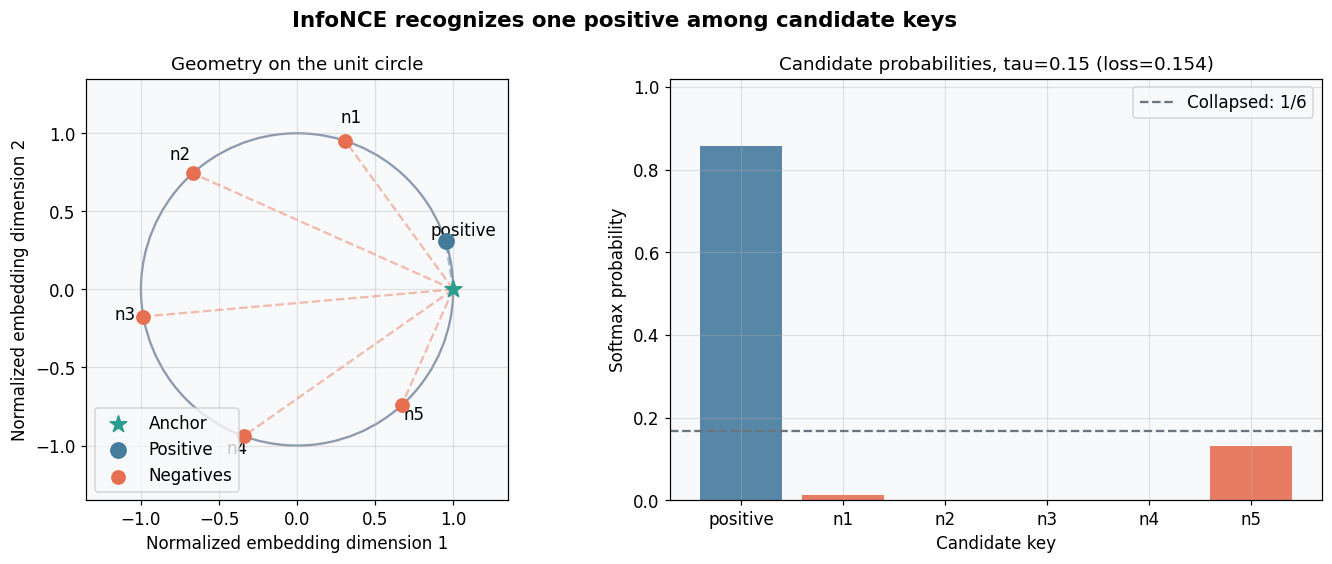

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
fig.suptitle('InfoNCE recognizes one positive among candidate keys', fontsize=14, fontweight='bold')

ax = axes[0]
circle = plt.Circle((0, 0), 1, fill=False, color='#8d99ae', linewidth=1.5)
ax.add_patch(circle)
ax.scatter(anchor[0], anchor[1], s=130, marker='*', color='#2a9d8f', label='Anchor', zorder=4)
ax.scatter(candidates[0, 0], candidates[0, 1], s=100, color='#457b9d', label='Positive', zorder=4)
ax.scatter(candidates[1:, 0], candidates[1:, 1], s=75, color='#e76f51', label='Negatives', zorder=4)
for index, point in enumerate(candidates):
    color = '#457b9d' if index == 0 else '#e76f51'
    ax.plot([anchor[0], point[0]], [anchor[1], point[1]], '--', color=color, alpha=0.45)
    ax.text(point[0] * 1.12, point[1] * 1.12, 'positive' if index == 0 else f'n{index}', ha='center')
ax.set_xlim(-1.35, 1.35)
ax.set_ylim(-1.35, 1.35)
ax.set_aspect('equal')
ax.set_xlabel('Normalized embedding dimension 1')
ax.set_ylabel('Normalized embedding dimension 2')
ax.set_title('Geometry on the unit circle')
ax.legend(loc='lower left')

ax = axes[1]
labels = ['positive', 'n1', 'n2', 'n3', 'n4', 'n5']
colors = ['#457b9d'] + ['#e76f51'] * 5
ax.bar(labels, probabilities, color=colors, alpha=0.9)
ax.axhline(collapsed_probability, color='#6c757d', linestyle='--', label=f'Collapsed: 1/{len(candidates)}')
ax.set_xlabel('Candidate key')
ax.set_ylabel('Softmax probability')
ax.set_title(f'Candidate probabilities, tau={temperature} (loss={loss_exp1:.3f})')
ax.set_ylim(0, 1.02)
ax.legend()

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** The positive has the smallest angle to the anchor and receives almost all probability. A collapsed representation would assign every candidate the dashed-line probability $1/K$.
2. **Why it looks this way:** Normalized dot products decrease with angle, and the softmax turns those similarities into a categorical prediction. Negatives make equal embeddings an avoidable, high-loss solution.
3. **Key takeaway:** InfoNCE is not merely a distance penalty; it asks the anchor to identify its positive relative to a dictionary.

---
## Experiment 2: Temperature selects the hard negatives

**Question:** Why does a small temperature concentrate learning on candidates that already resemble the anchor?

Temperature divides every similarity before softmax. It therefore changes both the probability distribution and the gradient scale without changing the ordering of candidates.

In [4]:
np.random.seed(2)
candidate_similarities = np.array([0.82, 0.72, 0.50, 0.20, -0.10])
candidate_labels = ['positive', 'hard neg', 'medium neg', 'easy neg', 'far neg']
temperatures = np.array([0.05, 0.10, 0.20, 0.50, 1.00])
temperature_probabilities = np.vstack([
    info_nce_from_similarities(candidate_similarities, tau)[1]
    for tau in temperatures
])
temperature_losses = np.array([
    info_nce_from_similarities(candidate_similarities, tau)[0]
    for tau in temperatures
])
hard_negative_gradient = temperature_probabilities[:, 1] / temperatures

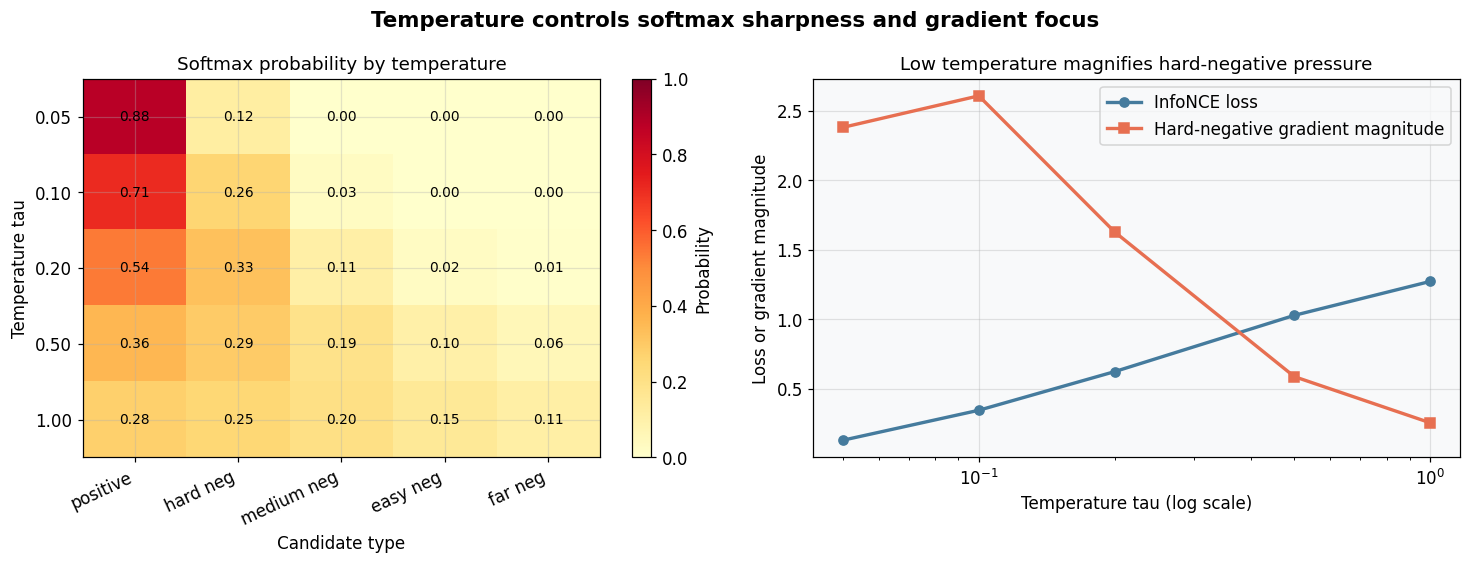

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))
fig.suptitle('Temperature controls softmax sharpness and gradient focus', fontsize=14, fontweight='bold')

ax = axes[0]
image = ax.imshow(temperature_probabilities, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(np.arange(len(candidate_labels)), candidate_labels, rotation=25, ha='right')
ax.set_yticks(np.arange(len(temperatures)), [f'{tau:.2f}' for tau in temperatures])
ax.set_xlabel('Candidate type')
ax.set_ylabel('Temperature tau')
ax.set_title('Softmax probability by temperature')
for row in range(len(temperatures)):
    for col in range(len(candidate_labels)):
        ax.text(col, row, f'{temperature_probabilities[row, col]:.2f}', ha='center', va='center', fontsize=9)
fig.colorbar(image, ax=ax, label='Probability')

ax = axes[1]
ax.plot(temperatures, temperature_losses, 'o-', linewidth=2.2, color='#457b9d', label='InfoNCE loss')
ax.plot(temperatures, hard_negative_gradient, 's-', linewidth=2.2, color='#e76f51', label='Hard-negative gradient magnitude')
ax.set_xscale('log')
ax.set_xlabel('Temperature tau (log scale)')
ax.set_ylabel('Loss or gradient magnitude')
ax.set_title('Low temperature magnifies hard-negative pressure')
ax.legend()

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** At low temperature, almost all negative probability is assigned to the hard negative. As temperature rises, probability spreads across even easy negatives and the hard-negative gradient weakens.
2. **Why it looks this way:** Dividing by a small $\tau$ amplifies logit gaps and contributes the explicit $1/\tau$ gradient factor. The closest wrong candidate dominates the update.
3. **Key takeaway:** Temperature is a hardness control. Very small values can accelerate discrimination, but they also amplify mislabeled or false negatives.

---
## Experiment 3: A larger dictionary makes the task more informative

**Question:** What happens to InfoNCE loss and its mutual-information lower bound as the number of negatives grows?

We sample one positive score from a high-similarity distribution and negatives from a lower-similarity distribution. The encoder is held fixed; only the candidate dictionary size changes.

In [6]:
np.random.seed(3)
dictionary_sizes = np.array([2, 4, 8, 16, 32, 64, 128, 256, 512])
trials = 2000
temperature_exp3 = 0.20
mean_losses = []
mean_bounds = []

for size in dictionary_sizes:
    positive_scores = np.random.normal(loc=0.65, scale=0.08, size=(trials, 1))
    negative_scores = np.random.normal(loc=0.00, scale=0.18, size=(trials, size - 1))
    logits = np.concatenate([positive_scores, negative_scores], axis=1) / temperature_exp3
    shifted = logits - logits.max(axis=1, keepdims=True)
    log_denominator = np.log(np.exp(shifted).sum(axis=1)) + logits.max(axis=1)
    losses = -logits[:, 0] + log_denominator
    mean_loss = losses.mean()
    mean_losses.append(mean_loss)
    mean_bounds.append(np.log(size) - mean_loss)

mean_losses = np.asarray(mean_losses)
mean_bounds = np.asarray(mean_bounds)
collapsed_losses = np.log(dictionary_sizes)

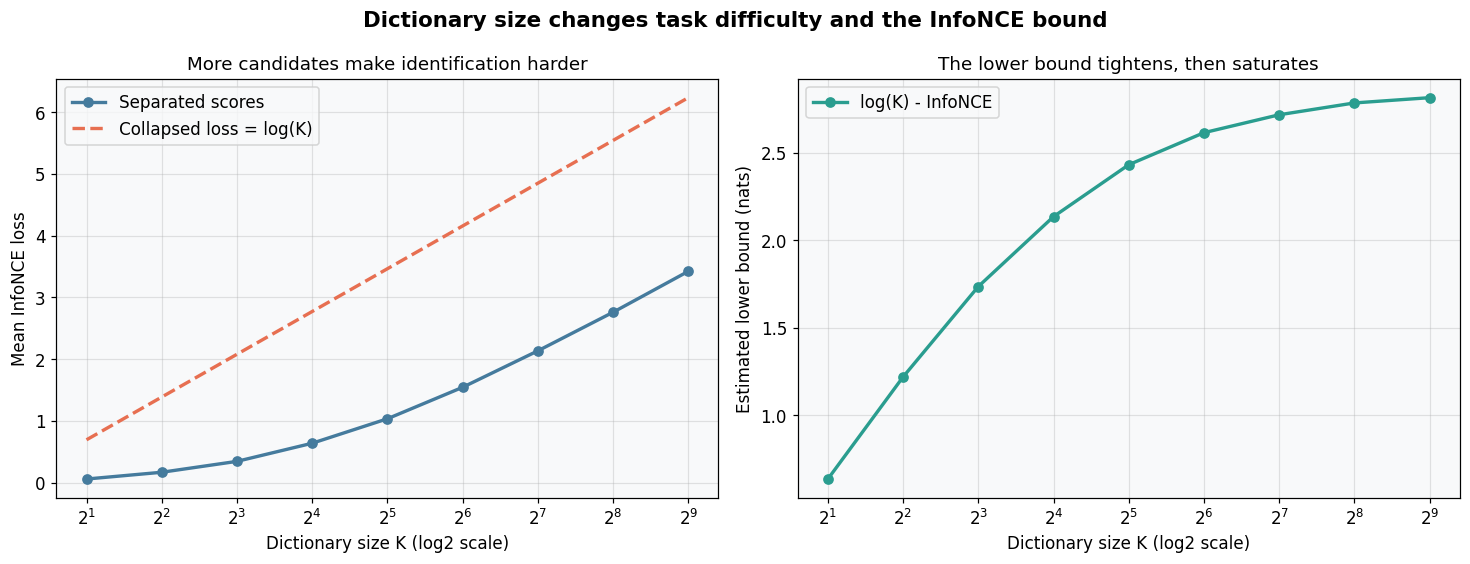

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))
fig.suptitle('Dictionary size changes task difficulty and the InfoNCE bound', fontsize=14, fontweight='bold')

ax = axes[0]
ax.plot(dictionary_sizes, mean_losses, 'o-', linewidth=2.2, color='#457b9d', label='Separated scores')
ax.plot(dictionary_sizes, collapsed_losses, '--', linewidth=2.2, color='#e76f51', label='Collapsed loss = log(K)')
ax.set_xscale('log', base=2)
ax.set_xlabel('Dictionary size K (log2 scale)')
ax.set_ylabel('Mean InfoNCE loss')
ax.set_title('More candidates make identification harder')
ax.legend()

ax = axes[1]
ax.plot(dictionary_sizes, mean_bounds, 'o-', linewidth=2.2, color='#2a9d8f', label='log(K) - InfoNCE')
ax.set_xscale('log', base=2)
ax.set_xlabel('Dictionary size K (log2 scale)')
ax.set_ylabel('Estimated lower bound (nats)')
ax.set_title('The lower bound tightens, then saturates')
ax.legend()

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** Loss rises with dictionary size because the positive competes with more candidates, but it stays far below the collapsed baseline. The quantity $\log K-\mathcal{L}$ improves before approaching a ceiling set by score overlap.
2. **Why it looks this way:** More negatives provide a harder density-ratio estimation problem and can tighten the InfoNCE mutual-information bound. Once likely hard negatives already appear, adding easy negatives contributes little new information.
3. **Key takeaway:** Large batches and MoCo queues are useful because they enlarge the dictionary, not because more negatives are universally better without limit.

---
## Experiment 4: False negatives receive the strongest repulsion

**Question:** What happens when a semantically related sample is placed in the denominator as a negative?

A false negative often resembles the anchor more than a true negative. InfoNCE cannot see semantic labels, so it treats this high similarity as a hard mistake and applies a large repulsive gradient.

In [8]:
np.random.seed(4)
false_negative_similarities = np.linspace(0.05, 0.90, 100)
positive_similarity = 0.82
true_negative_similarities = np.array([0.20, 0.05, -0.15, -0.30])
temperature_exp4 = 0.10
false_negative_losses = []
false_negative_gradients = []

for false_similarity in false_negative_similarities:
    similarities_exp4 = np.concatenate([[positive_similarity, false_similarity], true_negative_similarities])
    loss, probs = info_nce_from_similarities(similarities_exp4, temperature_exp4)
    false_negative_losses.append(loss)
    false_negative_gradients.append(probs[1] / temperature_exp4)

false_negative_losses = np.asarray(false_negative_losses)
false_negative_gradients = np.asarray(false_negative_gradients)
semantic_angles = np.deg2rad([0, 16, -18, 135, 220])
semantic_points = np.column_stack([np.cos(semantic_angles), np.sin(semantic_angles)])

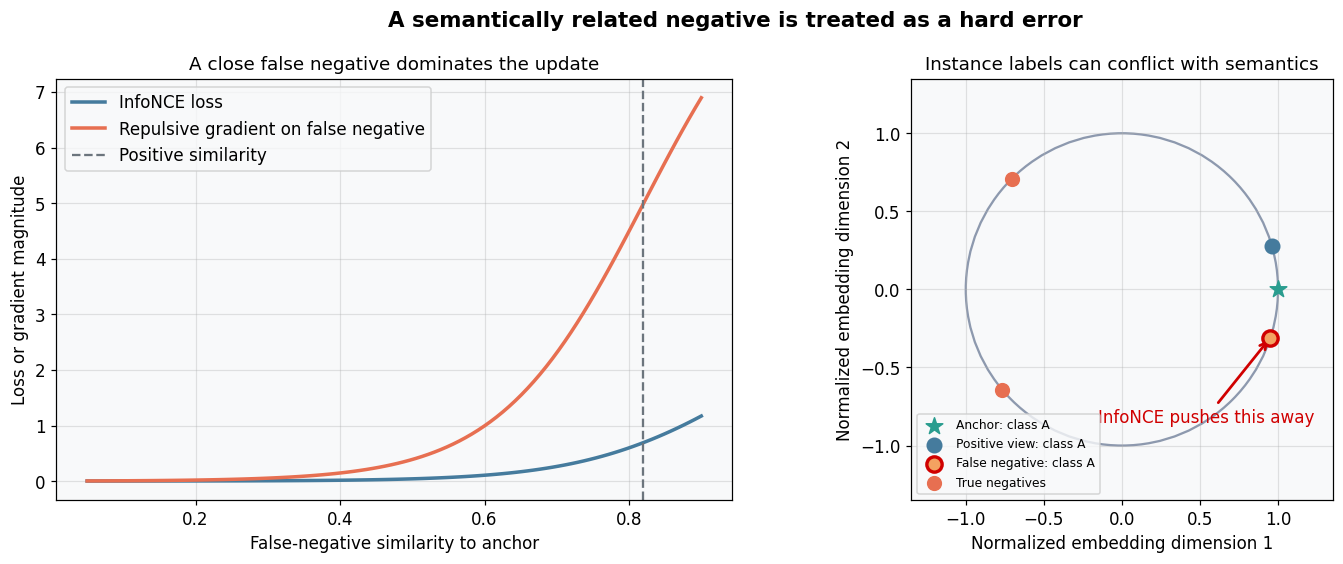

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))
fig.suptitle('A semantically related negative is treated as a hard error', fontsize=14, fontweight='bold')

ax = axes[0]
ax.plot(false_negative_similarities, false_negative_losses, linewidth=2.3, color='#457b9d', label='InfoNCE loss')
ax.plot(false_negative_similarities, false_negative_gradients, linewidth=2.3, color='#e76f51', label='Repulsive gradient on false negative')
ax.axvline(positive_similarity, color='#6c757d', linestyle='--', label='Positive similarity')
ax.set_xlabel('False-negative similarity to anchor')
ax.set_ylabel('Loss or gradient magnitude')
ax.set_title('A close false negative dominates the update')
ax.legend()

ax = axes[1]
circle = plt.Circle((0, 0), 1, fill=False, color='#8d99ae', linewidth=1.5)
ax.add_patch(circle)
ax.scatter(*semantic_points[0], s=130, marker='*', color='#2a9d8f', label='Anchor: class A', zorder=4)
ax.scatter(*semantic_points[1], s=90, color='#457b9d', label='Positive view: class A', zorder=4)
ax.scatter(*semantic_points[2], s=100, facecolor='#f4a261', edgecolor='#d00000', linewidth=2.2, label='False negative: class A', zorder=4)
ax.scatter(semantic_points[3:, 0], semantic_points[3:, 1], s=80, color='#e76f51', label='True negatives', zorder=4)
ax.annotate('InfoNCE pushes this away', xy=semantic_points[2], xytext=(-0.15, -0.85),
            arrowprops={'arrowstyle': '->', 'color': '#d00000', 'linewidth': 1.8}, color='#d00000')
ax.set_xlim(-1.35, 1.35)
ax.set_ylim(-1.35, 1.35)
ax.set_aspect('equal')
ax.set_xlabel('Normalized embedding dimension 1')
ax.set_ylabel('Normalized embedding dimension 2')
ax.set_title('Instance labels can conflict with semantics')
ax.legend(loc='lower left', fontsize=8)

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** As the false negative approaches the anchor, both loss and its repulsive gradient grow sharply. The geometric sketch shows the objective pushing apart two samples that belong to the same semantic class.
2. **Why it looks this way:** The softmax gives the largest negative probability to the most similar negative. Without labels, a useful neighbour and a genuinely confusing different-class sample are indistinguishable.
3. **Key takeaway:** Bigger dictionaries increase the chance of informative hard negatives and harmful false negatives at the same time.

---
## Summary / Key Takeaways

| Experiment | Key insight |
|---|---|
| 1. One positive among negatives | InfoNCE prevents complete collapse by requiring relative identification. |
| 2. Temperature | Low temperature concentrates probability and gradient on hard negatives. |
| 3. Dictionary size | More negatives can tighten the task and MI bound, but gains saturate. |
| 4. False negatives | The strongest repulsion may target a semantically useful neighbour. |

### Connection to the broader theory

Contrastive learning makes its anti-collapse mechanism explicit in the denominator. The next family of methods replaces a large negative dictionary with a slowly moving target encoder, then JEPA turns that stable target into a latent prediction problem.